having cleaned up the data, let's now look at it. 

We will be using the usual suspects, numpy, pandas, matplotlib, 
and also seaborn, a visualisation library that is built on top of the aformentioned ones. 

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_pickle('smfish.pkl')

In [3]:
#inspecting

df.head()

,FILE,CELL,AREA_cell,AREA_nuc,N_total,N_thres_Total,N_thres_Nuc,mrna,condition
0,WTGLU_01_CY3_outline.txt,Cell_CP_1,1256.0,223.0,3,3,2,DOA1,GLU
1,WTGLU_01_CY3_outline.txt,Cell_CP_2,1522.5,353.0,4,4,0,DOA1,GLU
2,WTGLU_01_CY3_outline.txt,Cell_CP_3,1778.0,431.0,3,3,1,DOA1,GLU
3,WTGLU_01_CY3_outline.txt,Cell_CP_4,472.0,214.0,2,2,1,DOA1,GLU
4,WTGLU_01_CY3_outline.txt,Cell_CP_5,1016.0,213.5,2,2,1,DOA1,GLU


## correlation of DOA1 and GAL1

In the syllabus, you saw scatterplots with histograms in the margins.
<br>
In seaborn, this type of plot is implemented as a jointplot:
<br>
Let's make one for the RAFF to GAL condition

In [4]:
# find unique entries in the condition column (i.e. the conditions)
df['condition'].unique()

array(['GLU', 'GLUGAL', 'RAFF', 'RAFFGAL'], dtype=object)

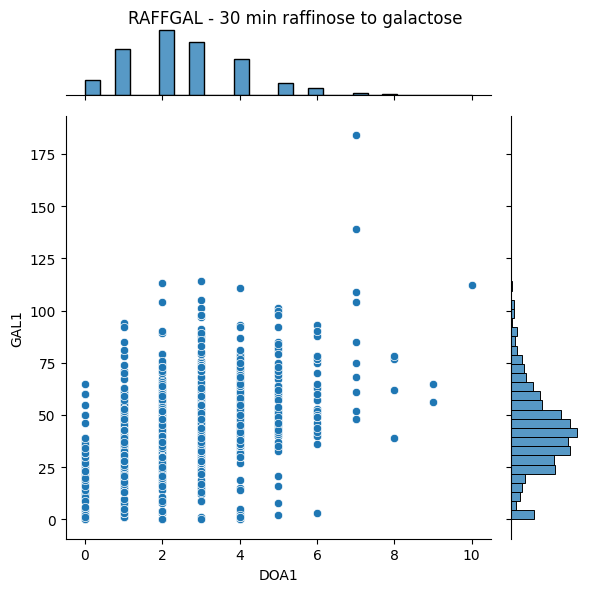

In [5]:
# extract the condition of interest:
data = df[df['condition']=='RAFFGAL']
data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')

g = sns.jointplot(data=data, x='DOA1', y='GAL1')
g.fig.suptitle('RAFFGAL - 30 min raffinose to galactose')
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.95)  # deja sitio para el título

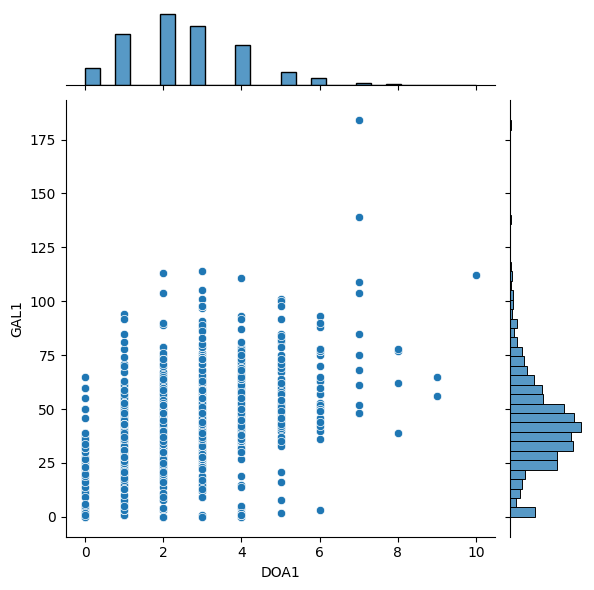

In [6]:
sns.jointplot(data=data, x='DOA1', y='GAL1')


### your turn:

repeat with the other conditions and compare.

What behaviour is expected?

you can change the scale of the plots by feeding xlim, ylim arguments:

`sns.jointplot(data=data, x='DOA1', y='GAL1', ylim=(-10,200), xlim=(0,20))`

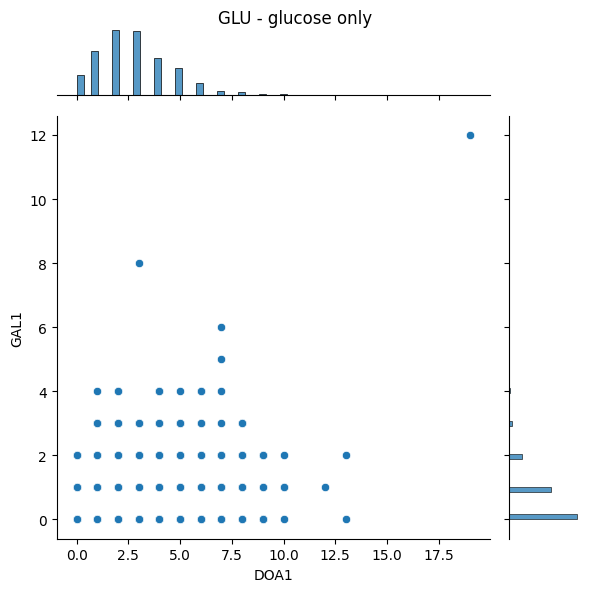

In [7]:
# your code here
data = df[df['condition']=='GLU']
data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')

g = sns.jointplot(data=data, x='DOA1', y='GAL1')
g.fig.suptitle('GLU - glucose only')
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.95)


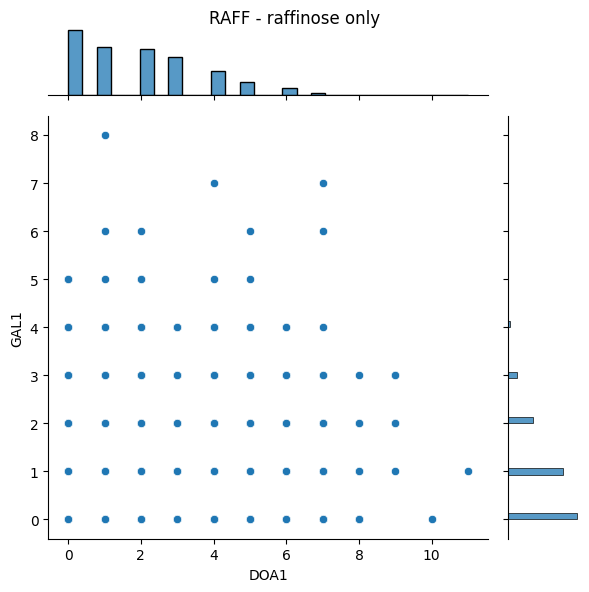

In [8]:
# your code here
data = df[df['condition']=='RAFF']
data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')

g = sns.jointplot(data=data, x='DOA1', y='GAL1')
g.fig.suptitle('RAFF - raffinose only')
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.95)

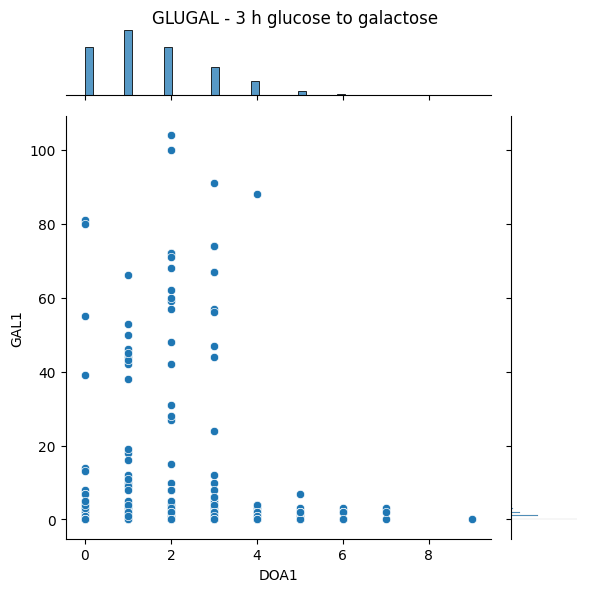

In [9]:
# your code here
data = df[df['condition']=='GLUGAL']
data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')

g = sns.jointplot(data=data, x='DOA1', y='GAL1')
g.fig.suptitle('GLUGAL - 3 h glucose to galactose')
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.95)


You can also visualise differences in conditions with a boxplot:

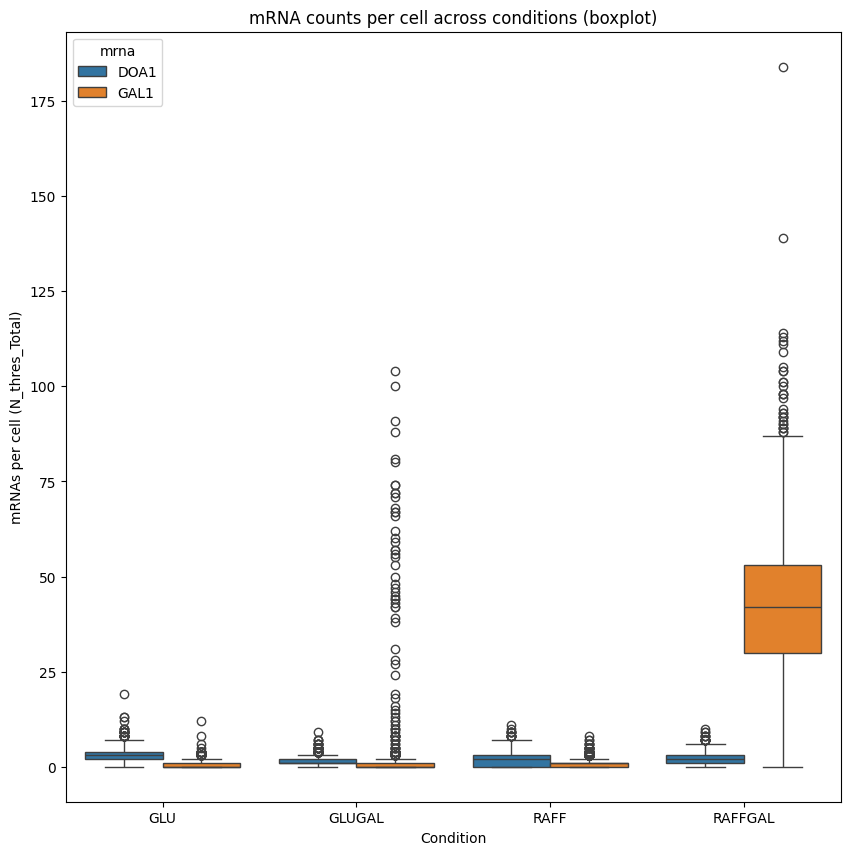

In [10]:
fig, ax= plt.subplots(figsize=(10,10,))

sns.boxplot(x='condition', y='N_thres_Total', data=df, hue='mrna')
ax.set_title('mRNA counts per cell across conditions (boxplot)')
ax.set_xlabel('Condition')
ax.set_ylabel('mRNAs per cell (N_thres_Total)')
plt.savefig('boxplot_conditions.png', bbox_inches='tight')

Alternatively, use a violinplot.

Seaborn implements violinplots in different ways.
Here, we use the 'violin' option in sns.catplot, which is short for categorical plot:

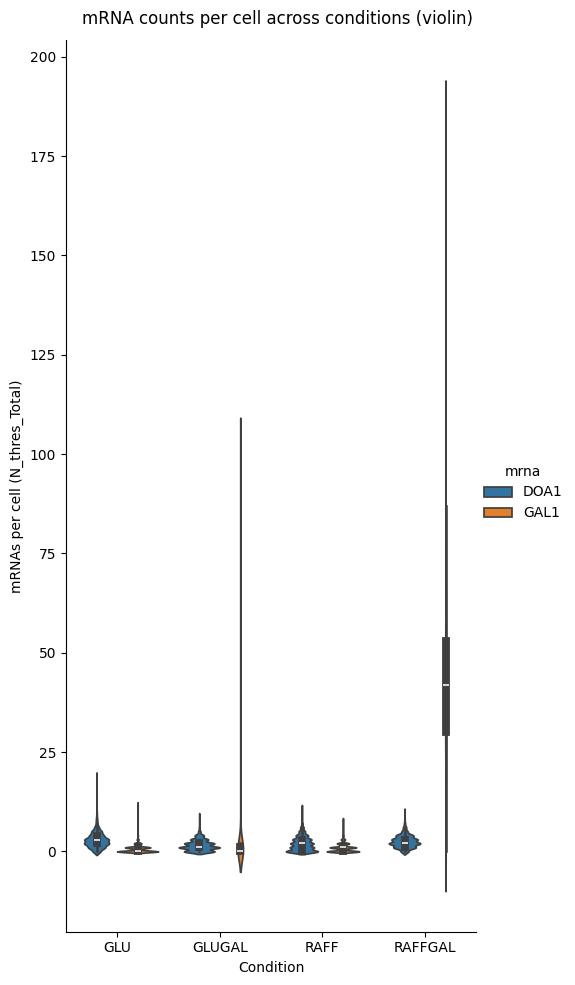

In [11]:
g = sns.catplot(
    x='condition', 
    y='N_thres_Total', 
    data=df, 
    hue='mrna', 
    kind='violin', 
    height=10, 
    aspect=0.5
)

g.fig.suptitle('mRNA counts per cell across conditions (violin)')
g.set_axis_labels('Condition', 'mRNAs per cell (N_thres_Total)')
g.fig.subplots_adjust(top=0.95)
g.savefig('violinplot_conditions.png')

Seaborn features many other kinds of plots to visualise data. One of the more important and useful ones is the dogplot, named with a nod to the catplot. The implementation is straightforward:

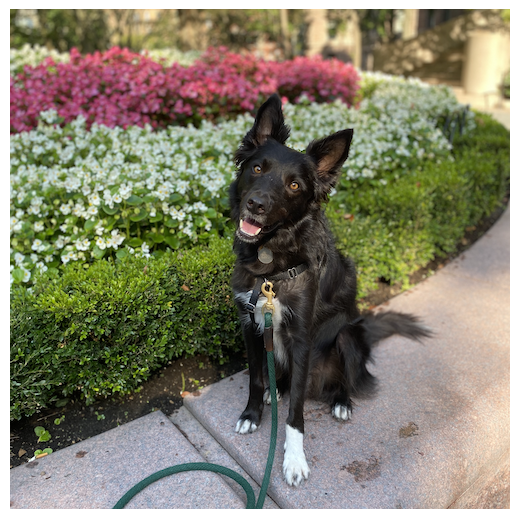

In [13]:
sns.dogplot(data=df, x='condition', y='N_thres_Total', border='collie')

### your turn:



What do you observe?
- DOA1 and GAL1 behave very differently across conditions, DOA1 stays within a similar low range in all four conditions, consistent with a constitutively active housekeeping gene independent of the carbon source. However GAL1 is almost silent under glucose and raffinose (GLU and RAFF), and strongly expressed after the transition to galactose (GLUGAL and RAFFGAL).

How do the differences in constitutively expressed and inducible mRNAs manifest themselves?


What effect does prior exposure to glucose have on the transition to galactose growth? 
- Prior exposure to glucose slows GLA1 induction, despite GLUGAL being sampled 3 hours after transition, while cells coming from raffinose show higher GAL1 levels just 30 min after.
Glucose actively represses GAL regulation, so glucose-exposed cells must first relieve this repression before being able to induce GAL1, while raffinose is not represing.

The transcript counts reflect how many cells are commiting to galactose growth. How do the data displayed here tie in with the remaining datasets?
- The single-cell GAL1 distributions show what fraction of the population has switch to galactose metabolism.
In GLUGAL most cells sit near zero GAL1 while a subset is induced, indicating a partial and heterogenous behaviour.

Which transition is noisier?
- GLUGAL (Glucose to Galactose)

Why?
- Its GAL1 distribution is broad and bimodal, as most cells sit near zero GAL1 expression, while some cells reach high counts, reflecting a cell-to-cell variability that arises from glucose repression (catabolic repression)
RAFFGAL is more homogeneous, with cells clustered around intermediate to high GAL1 levels.

The Boxplot and Violin plot reinforce this, as RAFFGAL show a distribution that shifts upward as a whole, indicating a more homogeneous response, while GLUGAL has a low GAL1 median with high outliers.

The two channels (CY3 and CY5) correspond to the two genes (GAL1 and DOA1)